In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [3]:
# import STAGATE
from utils import Cal_Spatial_Net, Stats_Spatial_Net, mclust_R
from Train_STAGATE import train_STAGATE

In [4]:
ROOT_PATH = Path('../../../data/MBA-MBP')
DATA_NAME = 'Mouse_Brain_Anterior'
adata_anterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_anterior.var_names_make_unique()

spatial_a=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Anterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_anterior.obs["x_array"]=spatial_a[2]
adata_anterior.obs["y_array"]=spatial_a[3]
adata_anterior.obs["x_pixel"]=spatial_a[4]
adata_anterior.obs["y_pixel"]=spatial_a[5]
adata_anterior.obs['boundary'] = 0
# adata_anterior.obs['x_pixel'] = adata_anterior.obsm['spatial'][:,0]
# adata_anterior.obs['y_pixel'] = adata_anterior.obsm['spatial'][:,1]
# make spot name unique
adata_anterior.obs_names = [x + '_anterior' for x in adata_anterior.obs_names]

# adata_anterior.layers['count'] = adata_anterior.X.toarray()
# sc.pp.normalize_total(adata_anterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_anterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable'] == True]
# sc.pp.scale(adata_anterior)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable']]
adata_anterior

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
DATA_NAME = 'Mouse_Brain_Posterior'
adata_posterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_posterior.var_names_make_unique()

spatial_p=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Posterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_posterior.obs["x_array"]=spatial_p[2]
adata_posterior.obs["y_array"]=spatial_p[3]
adata_posterior.obs["x_pixel"]=spatial_p[4]
adata_posterior.obs["y_pixel"]=spatial_p[5]
adata_posterior.obs['boundary'] = 0
# adata_posterior.obs['x_pixel'] = adata_posterior.obsm['spatial'][:,0]
# adata_posterior.obs['y_pixel'] = adata_posterior.obsm['spatial'][:,1]
# make spot name unique
adata_posterior.obs_names = [x + '_posterior' for x in adata_posterior.obs_names]

# adata_posterior.layers['count'] = adata_posterior.X.toarray()
# sc.pp.normalize_total(adata_posterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_posterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable'] == True]
# sc.pp.scale(adata_posterior)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable']]
adata_posterior

AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [6]:
obs_a = adata_anterior.obs
obs_p = adata_posterior.obs
# obs_p["x_pixel"]=obs_p["x_pixel"]-np.min(obs_p["x_pixel"])+np.min(obs_a["x_pixel"])
obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) - 150
# obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) + 1500

obs_a["boundary"] = 0
obs_p["boundary"] = 0

for i in list(set(obs_a['x_array'])):
    j = obs_a[obs_a['x_array'] == i].max()["y_array"]
    temp = obs_a[obs_a['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_a.loc[temp, "boundary"] = 1

for i in list(set(obs_p['x_array'])):
    j = obs_p[obs_p['x_array'] == i].min()["y_array"]
    temp = obs_p[obs_p['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_p.loc[temp, "boundary"] = 1

mean_a_y = obs_a[obs_a["boundary"] == 1]['x_pixel'].mean()
mean_p_y = obs_p[obs_p["boundary"] == 1]['x_pixel'].mean()
obs_p['x_pixel'] = obs_p['x_pixel'] + mean_a_y - mean_p_y

In [7]:
adata_anterior.obsm["spatial_aligned"] = adata_anterior.obs.loc[adata_anterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()
adata_posterior.obsm["spatial_aligned"] = adata_posterior.obs.loc[adata_posterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()

In [8]:
list_adata = [adata_anterior, adata_posterior]

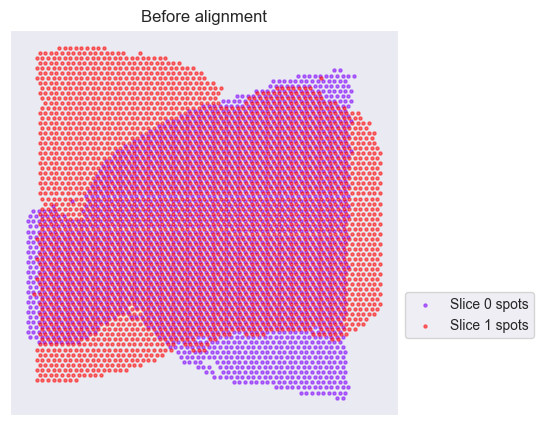

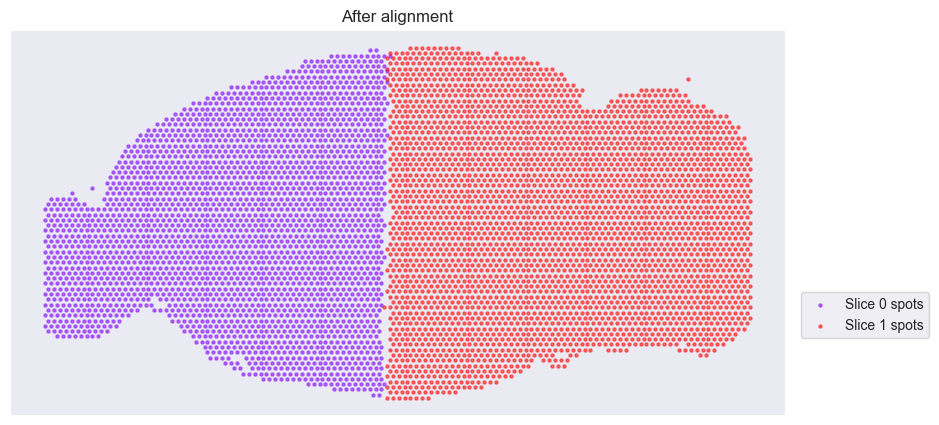

In [9]:
plot = True
coor_key = "spatial"
if plot:
    from matplotlib import cm
    import matplotlib
    import matplotlib.pyplot as plt

    # Choose colors
    cmap = cm.get_cmap('rainbow', len(list_adata))
    colors_list = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(len(list_adata))]

    # Plot spots before alignment
    plt.figure(figsize=(5, 5))
    plt.title("Before alignment")
    for i in range(len(list_adata)):
        plt.scatter(list_adata[i].obsm[coor_key][:, 0],
                    list_adata[i].obsm[coor_key][:, 1],
                    c=colors_list[i],
                    label="Slice %d spots" % i, s=5., alpha=0.5)
    ax = plt.gca()
    ax.set_ylim(ax.get_ylim()[::-1])
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc=(1.02, .2), ncol=(len(list_adata) // 13 + 1))
    plt.show()

if plot:
    plt.figure(figsize=(10, 5))
    plt.title("After alignment")
    for i in range(len(list_adata)):
        plt.scatter(list_adata[i].obsm["spatial_aligned"][:, 1],
                    list_adata[i].obsm["spatial_aligned"][:, 0],
                    c=colors_list[i],
                    label="Slice %d spots" % i, s=5., alpha=0.5)
    ax = plt.gca()
    ax.set_ylim(ax.get_ylim()[::-1])
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc=(1.02, .2), ncol=(len(list_adata) // 13 + 1))
    plt.show()

In [10]:
import anndata as ad
pre_adata = ad.concat(list_adata, label="batch_name", keys=['anterior', 'posterior'])
pre_adata.obs["batch_name"] = pre_adata.obs["batch_name"].astype('category')
pre_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    obsm: 'spatial', 'spatial_aligned'

In [11]:
slice_name_list = list(pre_adata.obs['batch_name'].unique())
slice_name_list

['anterior', 'posterior']

In [12]:
adata_list = {}
for section_id in slice_name_list:
    # input_dir = os.path.join('../../../data/MBA-MBP', section_id)
    # temp_adata = sc.read_visium(path=input_dir, count_file=section_id+'_filtered_feature_bc_matrix.h5')
    # temp_adata.var_names_make_unique()
    temp_adata = pre_adata[pre_adata.obs['batch_name']==section_id]

    # Truth_df = pd.read_csv(os.path.join('../../../data/DLPFC', section_id, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # temp_adata.obs['Ground Truth'] = Truth_df.loc[temp_adata.obs_names, 1]
    # make the spot name unique
    # temp_adata.obs_names = [x+'_'+section_id for x in temp_adata.obs_names]

    adata_list[section_id] = temp_adata.copy()

------Calculating spatial graph...
The graph contains 15656 edges, 2695 cells.
5.8093 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 19598 edges, 3355 cells.
5.8414 neighbors per cell on average.


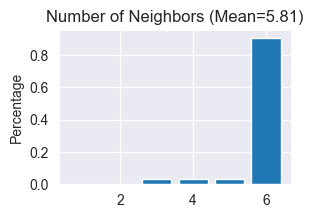

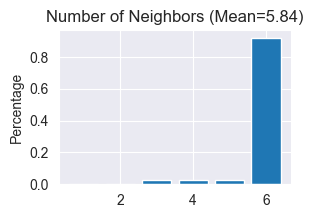

In [13]:
for section_id in slice_name_list:
    Cal_Spatial_Net(adata_list[section_id], rad_cutoff=150)
    Stats_Spatial_Net(adata_list[section_id])

In [14]:
adata = sc.concat([adata_list[x] for x in slice_name_list], keys=None)

In [15]:
adata.uns['Spatial_Net'] = pd.concat([adata_list[x].uns['Spatial_Net'] for x in slice_name_list])

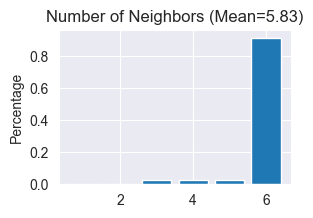

In [16]:
Stats_Spatial_Net(adata)

In [17]:
#Normalization
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [18]:
adata = train_STAGATE(adata)

Size of Input:  (6050, 2000)


100%|██████████| 1000/1000 [00:06<00:00, 156.48it/s]


In [19]:
adata.obs['Sample'] = [x.split('_')[-1] for x in adata.obs_names]

In [20]:
import harmonypy as hm

meta_data = adata.obs[['Sample']]

data_mat = adata.obsm['STAGATE']
vars_use = ['Sample']
ho = hm.run_harmony(data_mat, meta_data, vars_use)

res = pd.DataFrame(ho.Z_corr).T
res_df = pd.DataFrame(data=res.values, columns=['X{}'.format(i+1) for i in range(res.shape[1])], index=adata.obs.index)
adata.obsm[f'STAGATE.Harmony'] = res_df.to_numpy()

2025-08-06 14:32:20,589 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-06 14:32:22,075 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-06 14:32:22,116 - harmonypy - INFO - Iteration 1 of 10
2025-08-06 14:32:23,497 - harmonypy - INFO - Iteration 2 of 10
2025-08-06 14:32:24,715 - harmonypy - INFO - Iteration 3 of 10
2025-08-06 14:32:25,163 - harmonypy - INFO - Converged after 3 iterations


In [21]:
mclust_R(adata, used_obsm='STAGATE.Harmony', num_cluster=32)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'Sample', 'mclust'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_aligned', 'STAGATE', 'STAGATE.Harmony'

In [22]:
adata1 = adata[adata.obs['batch_name'] == 'anterior']

In [23]:
df_label = pd.read_csv('../../../data/MBA-MBP/Mouse_Brain_Anterior/Manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '_anterior' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [25]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total ARI:{ARI}")
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.40808304653901345
total NMI:0.6620616821290185
total AMI:0.6407508598703936
total ACC:0.651406270999706
total HOM:0.5906826408002778
total COM:0.7530630312799845
total V:0.6620616821290185


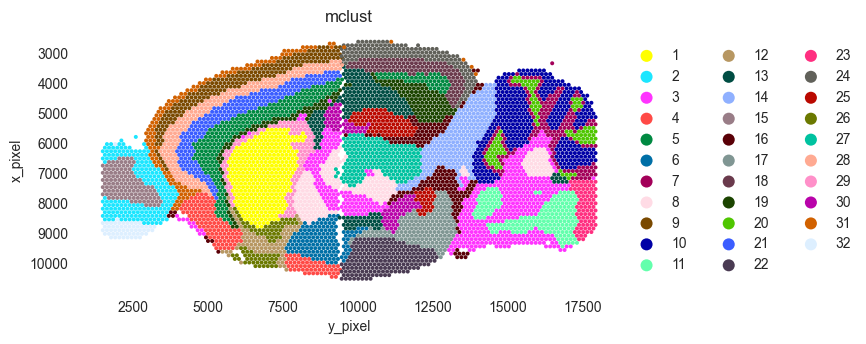

In [26]:
import matplotlib.pyplot as plt

plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

title = "STAGATE"
subadata = adata[~adata.obs['mclust'].isna()]  # 删除 NaN
ax=sc.pl.scatter(subadata,alpha=1,x="y_pixel",y="x_pixel",color="mclust",show=False,size=200000/adata.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.grid(False)